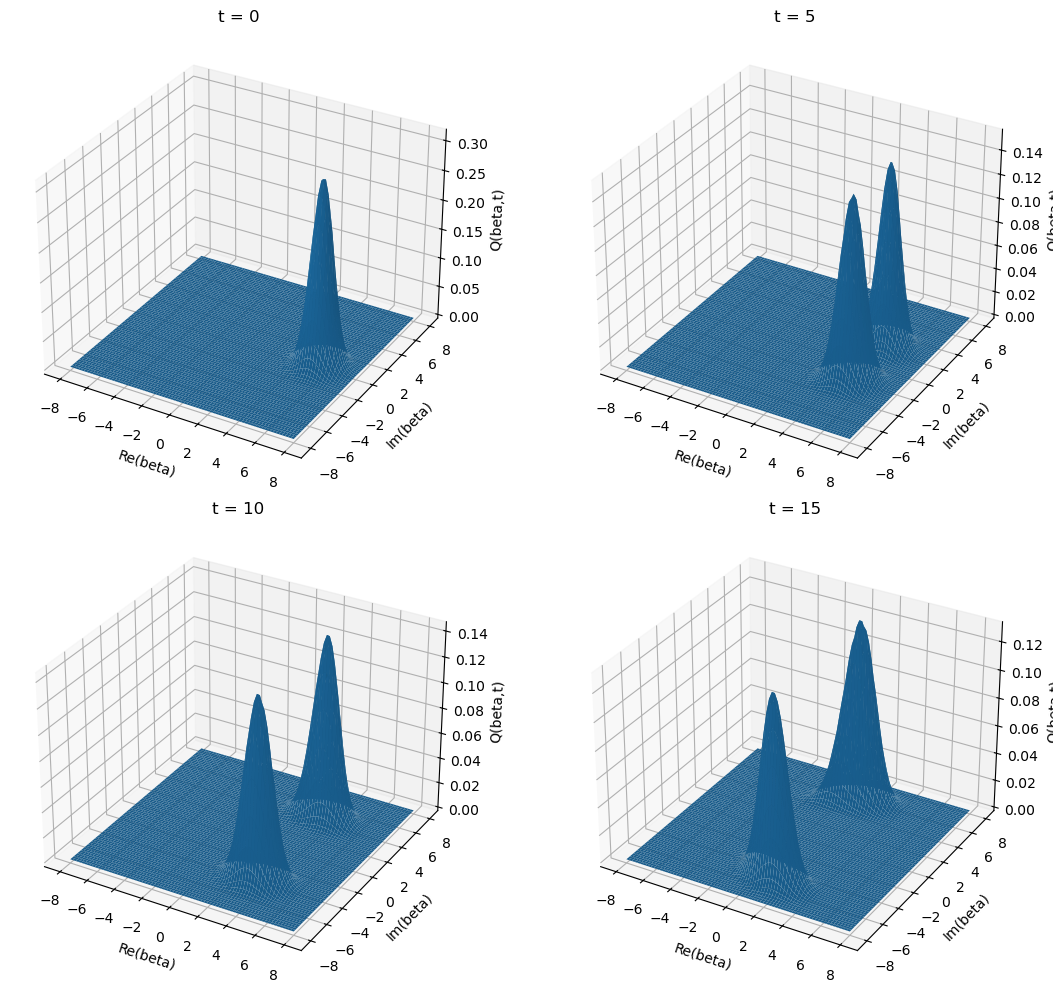

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
from mpl_toolkits.mplot3d import Axes3D

# parameters
alpha = np.sqrt(30)
lam = 1.0
nmax = 80

# choose times between t=0 and revival
times = [0,5,10,15]

# coefficients
def cg(N,t):
    return -1j*np.exp(-abs(alpha)**2/2)*(alpha**N/np.sqrt(float(factorial(N)))) \
           * np.sin(lam*t*np.sqrt(N+1))

def ce(N,t):
    return np.exp(-abs(alpha)**2/2)*(alpha**N/np.sqrt(float(factorial(N)))) \
           * np.cos(lam*t*np.sqrt(N+1))

# reduced density matrix
def rho_field(t):

    rho = np.zeros((nmax,nmax),dtype=complex)

    for N in range(nmax):
        for M in range(nmax):

            val = 0

            if N>0 and M>0:
                val += cg(N-1,t)*np.conjugate(cg(M-1,t))

            val += ce(N,t)*np.conjugate(ce(M,t))

            rho[N,M] = val

    return rho


# coherent state overlap
def coherent_component(beta,n):
    return np.exp(-abs(beta)**2/2) * beta**n / np.sqrt(float(factorial(n)))


# Q function
def Q(beta,rho):

    val = 0

    for n in range(nmax):
        for m in range(nmax):

            val += rho[n,m] * coherent_component(beta,n) \
                   * np.conjugate(coherent_component(beta,m))

    return np.real(val)/np.pi


# phase space grid
x = np.linspace(-8,8,80)
y = np.linspace(-8,8,80)

X,Y = np.meshgrid(x,y)

fig = plt.figure(figsize=(12,10))

for k,t in enumerate(times):

    rho = rho_field(t)

    Z = np.zeros_like(X)

    for i in range(len(x)):
        for j in range(len(y)):

            beta = X[i,j] + 1j*Y[i,j]
            Z[i,j] = Q(beta,rho)

    ax = fig.add_subplot(2,2,k+1,projection='3d')

    ax.plot_surface(X,Y,Z,rstride=1,cstride=1)

    ax.set_title(f"t = {t}")
    ax.set_xlabel("Re(beta)")
    ax.set_ylabel("Im(beta)")
    ax.set_zlabel("Q(beta,t)")

plt.tight_layout()
plt.show()